# **🧠 High-Level Pipeline Flow**

1. Input Microscope Image

2. YOLOv11 Object Detection

3. Bounding Box Extraction

4. Crop Detected Crystal Regions

5. Resize to 224×224

6. EfficientNetB0 Classification

7. Final Crystal Type Prediction


**✅ STEP 1: Load Trained Models**

In [1]:
!pip install ultralytics
from ultralytics import YOLO
import tensorflow as tf
import cv2
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
# Load YOLOv11 detection model
 # your trained YOLOv11 weights
yolo_model = YOLO("/content/drive/MyDrive/Crystal_Detection_Results/yolo11m_crystal_v1/weights/best.pt")

# Load EfficientNet classification model
cnn_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/efficientnet_crystals_best_v2.keras"
)

class_names = [
    "CaOx_Dihydrate",
    "CaOx_Monohydrate",
    "Phosphate",
    "Uric_Acid"
]


# **✅ STEP 2: Run YOLO Detection on a New Image**

In [6]:
image_path = "/content/drive/MyDrive/c3.jpg"
results = yolo_model(image_path)

img = cv2.imread(image_path)
h, w, _ = img.shape



image 1/1 /content/drive/MyDrive/c3.jpg: 480x640 3 crystals, 29.8ms
Speed: 2.5ms preprocess, 29.8ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


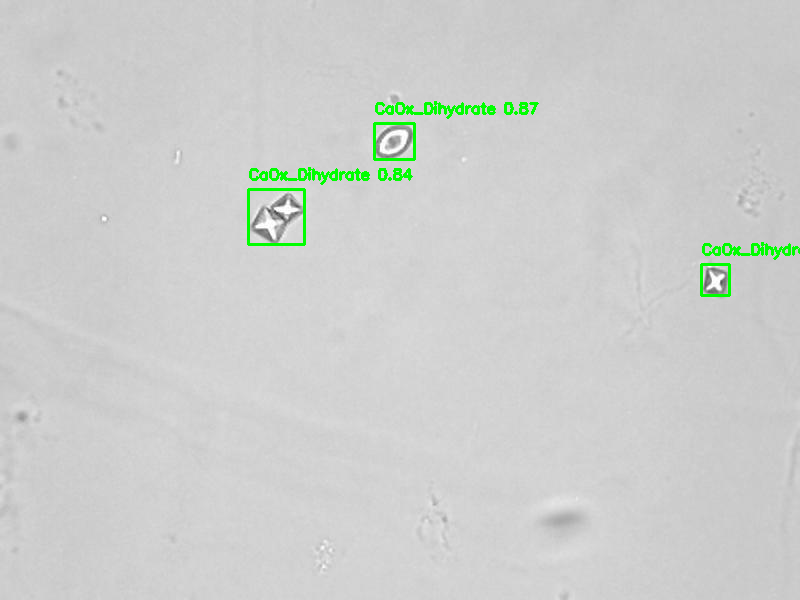

In [8]:
from google.colab.patches import cv2_imshow

annotated_img = img.copy()

for box in results[0].boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    # Draw rectangle
    cv2.rectangle(annotated_img, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green box, 2px thickness

    # Put label and confidence
    label = f"{class_names[class_id]} {confidence:.2f}"
    cv2.putText(annotated_img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

cv2_imshow(annotated_img)

# **✅ STEP 3: Crop Detected Crystals (Critical Step)**

In [9]:
crops = []

for box in results[0].boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    crop = img[y1:y2, x1:x2]

    if crop.size == 0:
        continue

    crops.append(crop)


# **✅ STEP 4: Preprocess Crop for CNN**

In [10]:
def preprocess_for_cnn(crop):
    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    crop = cv2.resize(crop, (224, 224))
    crop = tf.keras.applications.efficientnet.preprocess_input(crop)
    crop = np.expand_dims(crop, axis=0)
    return crop


# **✅ STEP 5: Classify Each Cropped Crystal**

In [11]:
for i, crop in enumerate(crops):
    input_tensor = preprocess_for_cnn(crop)
    preds = cnn_model.predict(input_tensor)

    class_id = np.argmax(preds)
    confidence = np.max(preds)

    print(f"Crystal {i+1}: {class_names[class_id]} ({confidence*100:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Crystal 1: CaOx_Monohydrate (100.00%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Crystal 2: CaOx_Dihydrate (99.94%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Crystal 3: CaOx_Dihydrate (100.00%)


# **✅ STEP 6 (Optional but Recommended): Visualize Results**

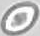

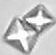

In [12]:
from google.colab.patches import cv2_imshow

for i, crop in enumerate(crops):
    cv2_imshow(crop)
    # cv2.waitKey(0) # waitKey is not typically used with cv2_imshow in Colab

# cv2.destroyAllWindows() # Not necessary with cv2_imshow